# This notebook walks through recording extracellular voltage using the simulator 

In [738]:
# Imports and loading of NEURON dll
import numpy as np
from neuron import h
import simulation as sim
import matplotlib.pyplot as plt
import extracellular as ex
import helperFuncs as hf

## Collect important functions at the top

In [739]:
## Function to return extracellular voltage at recElec
def extracellular_voltage(Stim,RGC,iOut,recElec,stim_type='clamp'):
    # setup vector where to store extracellular voltage profile
    if stim_type == 'clamp':
        timeStepsRec = int(h.tstop/h.dt)+1
        dtFac = 1
        recOut = np.zeros((timeStepsRec))
    elif stim_type == 'extra':
        timeStepsRec = int(Stim['stop']/Stim['dt'])+1
        dtFac = 1
        recOut = np.zeros((timeStepsRec))


    # Setup transfer impedance between recording electrode and cell, then 
    #  scale recorded membrane currents to get extracellular voltage profile 
    for section in RGC.section_list:
        # print(section.name())
        # Loop over all segments in section
        for seg, k in zip(section,range(section.nseg)):
            # Distance from electrode to center of each segment [cm]
            r = 1e-4*\
                np.sqrt((seg.xtra.x - (recElec[0]))**2\
                        + (seg.xtra.y - (recElec[1]))**2)
            # Vertical distance [cm]
            z = 1e-4*(seg.xtra.z-recElec[2])

            # Transfer impedance [MOhm]  
            rDisk = 1e-4*Stim['elecDiam']/2             
            tf = 1e-6*(2.0*Stim['rhoExt'])/(4.0*np.pi*rDisk) \
                * np.arcsin((2*rDisk) / \
                (np.sqrt((r-rDisk)**2+z**2)+np.sqrt((r+rDisk)**2+z**2)))
                        
            # recOut units: 1e3*MOhm*nA == uV
            if stim_type == 'clamp':
                recOut += 1e3 * tf * \
                    (iOut[section.name()]['imem' + str(k)].as_numpy())
            elif stim_type == 'extra':
                recOut += 1e3 * tf * \
                    (iOut[section.name()]['imem' + str(k)].as_numpy()[int(Stim['initDur']/Stim['initDt'])::dtFac])
                
    return recOut # units: [uV]

In [740]:
def extract_signal_window(ei1, ei2):
    """
    Extract a window of 200 samples before and 200 samples after the negative peak for each electrode.
    
    Parameters:
    ei1, ei2: numpy arrays of shape (519, 25001)
        The spatiotemporal arrays representing the recorded spikes.
    
    Returns:
    tuple of numpy arrays
        The extracted signal windows from ei1 and ei2.
    """
    # Initialize lists to store the extracted windows
    extracted_ei1 = []
    extracted_ei2 = []
    
    # Iterate over each row (electrode)
    for row1, row2 in zip(ei1, ei2):
        # Find the index of the negative peak for both signals
        peak_idx1 = np.argmin(row1)
        peak_idx2 = np.argmin(row2)
        
        # Confirm that the negative peak indices are equal
        if peak_idx1 != peak_idx2:
            raise ValueError("The negative peak indices do not match between ei1 and ei2.")
        
        # Extract 200 samples before and 200 samples after the negative peak
        start_idx = max(0, peak_idx1 - 300)
        end_idx = min(len(row1), peak_idx1 + 300 + 1)
        
        extracted_ei1.append(row1[start_idx:end_idx])
        extracted_ei2.append(row2[start_idx:end_idx])
    
    # Also return time t which is len(row) * 0.005 ms
    t = np.arange(-300, 301) * 0.005
    
    # Convert the lists to numpy arrays
    extracted_ei1 = np.array(extracted_ei1)
    extracted_ei2 = np.array(extracted_ei2)
    
    return extracted_ei1, extracted_ei2, t

In [741]:
def preprocess_ei(ei1, ei2):
    """
    Calculate the Mean Squared Error (MSE) between two electrical images (EIs).
    
    Parameters:
    ei1: numpy array of shape (519, 61)
        The spatiotemporal array representing the recorded spikes, sampled every 0.05 ms.
    ei2: numpy array of shape (519, 25001)
        The spatiotemporal array representing the recorded spikes, sampled every 0.005 ms.
    
    Returns:
    float
        The MSE between the filtered EIs.
    """
    # Find significant electrodes based on minimum value < -5
    significant_mask = np.min(ei1, axis=1) < -5
    
    # Apply the mask to both EIs to get only significant rows
    trimmed_ei1 = ei1[significant_mask]
    trimmed_ei2 = ei2[significant_mask]

    # Go one row at a time and align the signals
    for ii in range(trimmed_ei1.shape[0]):
        # Get the data vector for that row (electrode)
        ei1_row = trimmed_ei1[ii]
        ei2_row = trimmed_ei2[ii]

        # Create a time vector, noting that the sampling rate is different
        t1 = np.arange(0, ei1_row.size*0.05, 0.05)
        t2 = np.arange(0, ei2_row.size*0.005, 0.005)

        # Align the signals so the negative peaks are aligned in time
        peak_real = np.argmin(ei1_row)
        peak_sim = np.argmin(ei2_row)

        # Shift model data to align with real data, account for different time scales
        shift = t2[peak_sim] - t1[peak_real]
        t_sim_shift = t2 - shift 

        # Now the two signals are aligned in time, upsample the real data to match the resolution of the simulated data
        aligned_ei1 = np.interp(t_sim_shift, t1, ei1_row)


        # create e1_filtered row ii is aligned_ei1 and e2_filtered row ii is ei2_row
        if ii == 0:
            ei1_filtered = aligned_ei1
            ei2_filtered = ei2_row
        else:
            ei1_filtered = np.vstack((ei1_filtered, aligned_ei1))
            ei2_filtered = np.vstack((ei2_filtered, ei2_row))

    # Window the signals
    ei1_filtered, ei2_filtered, t = extract_signal_window(ei1_filtered, ei2_filtered)

    return ei1_filtered, ei2_filtered, t

## Step 1: Setup simualted cell

### Hard reset to delete any lingering segments 

In [742]:
# clear all NEURON sims. Required if you are going to be running many exps
#  in Jupyter notebooks.
for sec in h.allsec():
   h.delete_section(sec=sec)

### Build a cell, point to the params file of interest 

In [743]:
# Code to setup a single simulated RGC
# Default params file located at: 'cell_param_files/params_35.csv'
RGC = sim.Local_Cell()
filename = 'cell_param_files/params_35_v2.csv'
RGC.build_cell(filename,'mammalian_spike_35')

### Output simple facts: (x,y,z) of soma center and all compartments 

In [744]:
# print out where the center of the soma is located and shift if needed
#  Note, behind the scenes this is shifting all simualted compartments by 
#  the necessary x,y,z transforms to get the cell to the right spot 
print('Current soma center is located at: ', RGC.soma_center) # units: [um]

# convert degrees to radians
#  by default the axon points towards -x, so a 90 degree rotation would make it 
#  point in the -y direction 
degrees = 100
radians = np.deg2rad(degrees)

RGC._rotateZ(radians)
print('New soma center is located at: ', RGC.soma_center)

RGC.shift_cell_x_y_z(-45,410,0)
print('New soma center is located at: ', RGC.soma_center)

Current soma center is located at:  [-11.9399995803833, 0.0, 10.0]
New soma center is located at:  [-11.9399995803833, 0.0, 10.0]
New soma center is located at:  [-30.98664093017578, 398.24139404296875, 0.0]


## Step 2: Setup electrical stimulus 

In [745]:
### Most features of the stimulus are set up a struct (dict) called Stim 
Stim = {}

# temporal features of the sitmulus 
Stim['pulseShape'] = 'triphasic'
Stim['dt'] = .005 # units: [ms]
Stim['delay'] = 10 # units: [ms]
Stim['dur'] = 0.05 # units: [ms]
Stim['stop'] = 80 # units: [ms]
Stim['amp'] = 2.5 # units: [uA]

# calibration phase of the stimulus 
Stim['initDur'] = 50 # units: [ms]
Stim['initDt'] = 1 # units: [ms]
Stim['vInit'] = -70 # units: [mV] #TODO: Old is -70

# spatial features of the stimulus 
# --> specifically defining the electrode geometry 
Stim['electrodes'] = [[-10,0,40]] # units: [um] 
Stim['electrode_type'] = 'disk'
Stim['rhoExt'] = 1000 # Ohm*cm
Stim['elecDiam'] = 15 # um
Stim['polarity'] = -1 # anodic == 1; cathodic == -1 

Stim['pulseRatioTri'] = [-2/3,1,-1/3]
Stim['pulseRatioBi'] = [1,-1]
Stim['frequency'] = 10 # units: [Hz]

## Step 3: Set up recording vectors in order to probe what happened 

### Current recording vectors at all segment compartments

In [746]:
# Setup dictionary to capture iOut at all cell compartments
iOut = {}
h.cvode.use_fast_imem(True) # needed for i_membrane_ / extracellular recording
for section in RGC.section_list:
    iOut[section.name()] = {}
    for seg, i in zip(section,range(section.nseg)):
        iOut[section.name()]['imem' + str(i)] = h.Vector().record(seg._ref_i_membrane_)

### Voltage recording vectors at all segment compartments 

In [747]:
vOut = {}
for section in RGC.section_list:
    vOut[section.name()] = {}
    for seg, i in zip(section,range(section.nseg)):
        vOut[section.name()]['vmem' + str(i)] = h.Vector().record(seg._ref_v)

### Time vector

In [748]:
# set up recoring vector for time in the simulation 
t = h.Vector().record(h._ref_t)

## Step 4: Apply stimulus to the cell! (Run only one cell below)

In [749]:
# First, decide if you want current clamp (visually-) or electrode 
#   current (extracellularly-) evoked spiking
stim_type = 'clamp' # 'clamp' or 'extra'

In [750]:
if stim_type == 'clamp':
    # Current clamp simulation
    h.init()
    h.v_init = -64 # Old = -70
    h.finitialize(h.v_init)
    h.fcurrent()
    h.dt = 0.001
    h.tstop = 25

    # # Create intracellular stimulus
    # CurrentClamp = h.IClamp(0.5,sec=RGC.cell.soma) # inject current to soma
    # # CurrentClamp = h.IClamp(1,sec=h.axon) # inject current to axon
    # CurrentClamp.delay= 1 # msec
    # CurrentClamp.dur= 0.15 # msec
    # CurrentClamp.amp= 3.9 # nA

    # Create intracellular stimulus
    CurrentClamp = h.IClamp(0.5,sec=RGC.cell.dend[0]) # inject current to soma
    # CurrentClamp = h.IClamp(1,sec=h.axon) # inject current to axon
    CurrentClamp.delay= 1 # msec
    CurrentClamp.dur= 0.15 # msec
    CurrentClamp.amp= 2.9 # nA

    # run sim!
    h.run()
elif stim_type == 'extra':
    # Need to do this everytime the stimulus parameters are changed
    hf.setupTransferImpedance(Stim, RGC)

    # Play the stimulus into the cell, setting it up for stimulation
    Stim['amp'] = Stim['polarity']*Stim['amp']
    tsvec, isvec = hf.setupStimulus(Stim)
    isvec.play(h._ref_is_xtra, tsvec, 1) 

    # Initialization phase of the simulation 
    h.init()
    h.tstop = Stim['initDur']
    h.dt = Stim['initDt']
    h.finitialize(Stim['vInit'])
    h.continuerun(h.tstop)

    # Run the simulation 
    h.tstop = Stim['initDur'] + Stim['stop']
    h.steps_per_ms = int(1/Stim['dt'])
    h.dt = Stim['dt']
    h.continuerun(h.tstop)
    print('***** sim done *****')

## Plot simulated cell over the entire electrode array

In [751]:
# import electrode array (30um)
electrodes = hf.generate_electrode_map(519)

In [752]:
# Load experimental data and overlay on plot

import visionloader as vl

## -------------
# datapath = '/Volumes/Analysis/2020-10-06-7/kilosort_data000/data000'
# datarun = 'data000'
# vcd = vl.load_vision_data(datapath,datarun,
#                           include_neurons=True,
#                           include_ei=True,
#                           include_params=True,
#                           include_noise=True)

# # TODO: pick cell ID
# ei_real = vcd.get_ei_for_cell(535).ei
# print(ei_real.shape)
## -------------

datapath = '/Volumes/Analysis/2020-10-06-7/kilosort_data000/data000'
datarun = 'data000'
vcd = vl.load_vision_data(datapath,datarun,
                          include_neurons=True,
                          include_ei=True,
                          include_params=True,
                          include_noise=True)

# TODO: pick cell ID
ei_real = vcd.get_ei_for_cell(292).ei
print(ei_real.shape)

# collapse ei into just minimum for every row, call it ei_min
ei_min_real = -3.6*np.min(ei_real,axis=1) # convert to uV
print(ei_min_real.shape)
print(np.max(ei_min_real))

(519, 61)
(519,)
183.69743


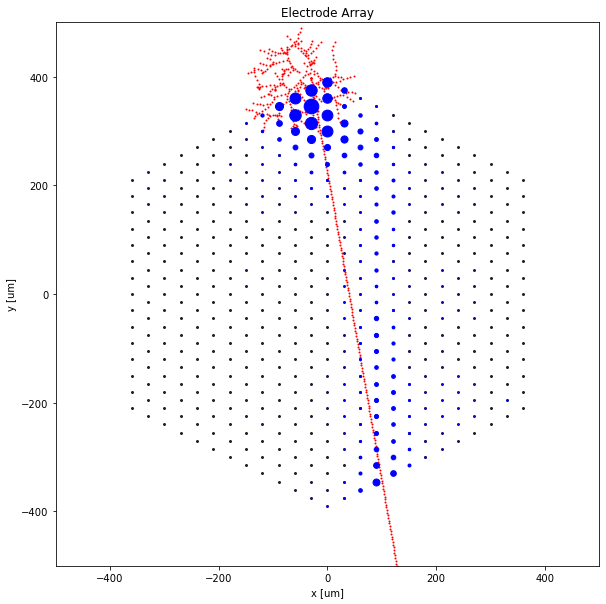

In [753]:
# Plot the simulated cell on the electrode array 
# plot electrode array using plt
fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(111)
                    
for ii,elec in enumerate(electrodes):
    ax.plot(elec[0],elec[1],'o',color='black',markersize=2,alpha=0.8)

for sec in RGC.section_list:
    for seg in sec:
        ax.plot(seg.x_xtra,seg.y_xtra,'o',color='red',markersize=1)

for ii,elec in enumerate(electrodes):
    # ax.plot(elec[0],elec[1],'o',color='grey',markersize=2,alpha=0.8)
    # ax2.plot(elec[0],elec[1],'o',color='grey',markersize=2,alpha=0.8)

    ax.plot(elec[0],elec[1],'o',color='blue',markersize=ei_min_real[ii]*.08)

ax.set_aspect('equal')
plt.xlim([-500,500])
plt.ylim([-500,500])
plt.xlabel('x [um]')
plt.ylabel('y [um]')
plt.title('Electrode Array')
plt.show()

## Generate simulated EI

In [757]:
# Get extracellular voltage profile for each electrode
z = 48+10
ei_sim = []
for elec in electrodes:
    recElec = [elec[0],elec[1],z]
    recOut = extracellular_voltage(Stim,RGC,iOut,recElec)
    ei_sim.append(recOut)

In [758]:
ei_min_sim = -1*np.min(ei_sim,axis=1)
np.max(ei_min_sim)

311.82520118858224

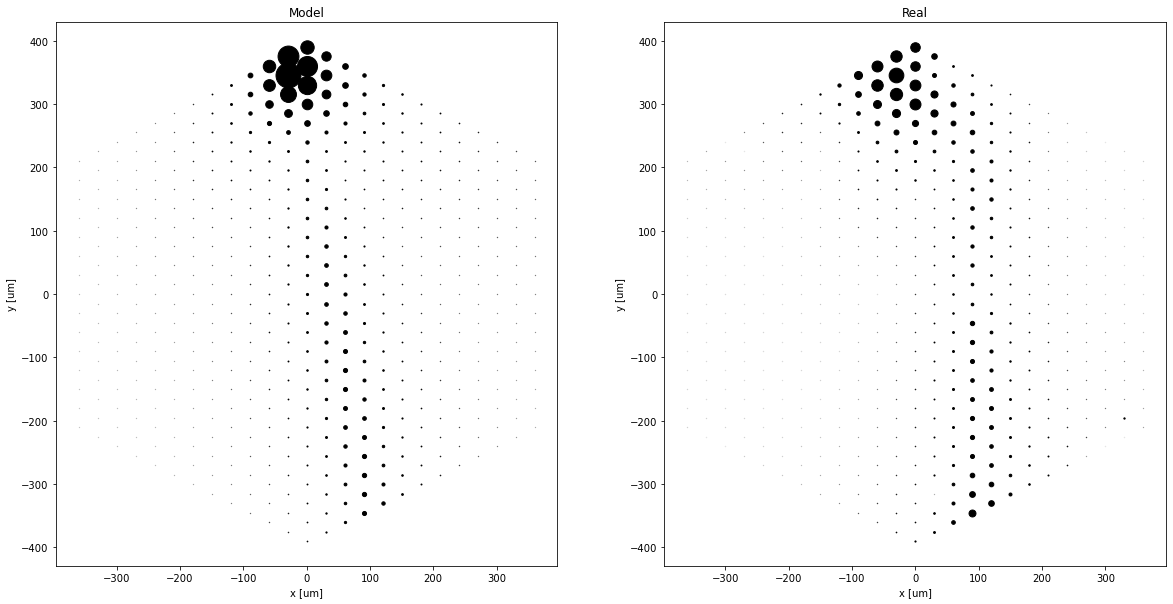

In [759]:
# plot electrode array using plt
fig = plt.figure(figsize=(20,10))

# side by side subplots

ax = fig.add_subplot(121)
ax2 = fig.add_subplot(122)
                    
for ii,elec in enumerate(electrodes):
    # ax.plot(elec[0],elec[1],'o',color='grey',markersize=2,alpha=0.8)
    # ax2.plot(elec[0],elec[1],'o',color='grey',markersize=2,alpha=0.8)

    ax.plot(elec[0],elec[1],'o',color='grey',markersize=0.5,alpha=0.2)
    ax.plot(elec[0],elec[1],'o',color='black',markersize=ei_min_sim[ii]*.08)
    ax2.plot(elec[0],elec[1],'o',color='grey',markersize=0.5,alpha=0.2)
    ax2.plot(elec[0],elec[1],'o',color='black',markersize=ei_min_real[ii]*.08)

    

# # ----------------- plot X on selected electrodes -----------------
# electrodes_to_plot = [482,444]

# for elec in electrodes_to_plot:
#     ax.plot(electrodes[elec][0],electrodes[elec][1],'X',color='black',markersize=10)
#     ax2.plot(electrodes[elec][0],electrodes[elec][1],'X',color='black',markersize=10)
# # ----------------- plot X on selected electrodes -----------------

# electrodes_to_plot = [482,444]

# for elec in electrodes_to_plot:
#     ax.text(electrodes[elec][0],electrodes[elec][1],str(elec),fontsize=10)
#     ax2.text(electrodes[elec][0],electrodes[elec][1],str(elec),fontsize=10)

# ------------ plot electrode numbers -----------
# k = 1
# for elec in electrodes:
#     # Plot electrode number identified by str(k) at electrode locations
#     ax.text(elec[0]+5,elec[1]+5,str(k),fontsize=10)
#     k += 1
# ------------ plot electrode numbers -----------

ax.set_aspect('equal')
ax2.set_aspect('equal')
ax.set_title('Model')
ax2.set_title('Real')
ax.set_xlabel('x [um]')
ax.set_ylabel('y [um]')
ax2.set_xlabel('x [um]')
ax2.set_ylabel('y [um]')
# plt.savefig("figures/figure2_A.pdf",format="pdf", bbox_inches="tight")
plt.show()

## Compute peak correlation between simulated and real EI

In [760]:
ei_real_array = np.array(ei_real)*3.6
ei_sim_array = np.array(ei_sim)   

In [761]:
print(ei_real_array.shape)
print(ei_sim_array.shape)

(519, 61)
(519, 25001)


In [762]:
ei_real, ei_sim, t  = preprocess_ei(ei_real_array, ei_sim_array)

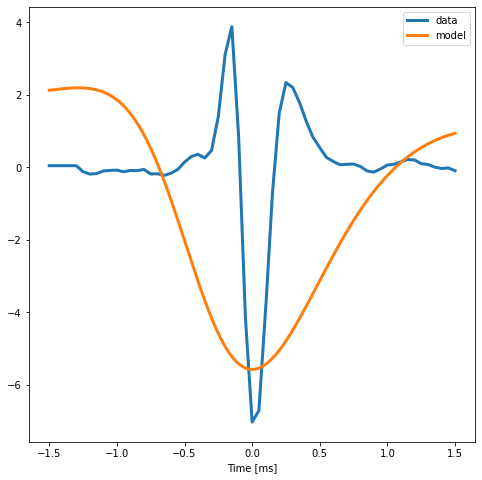

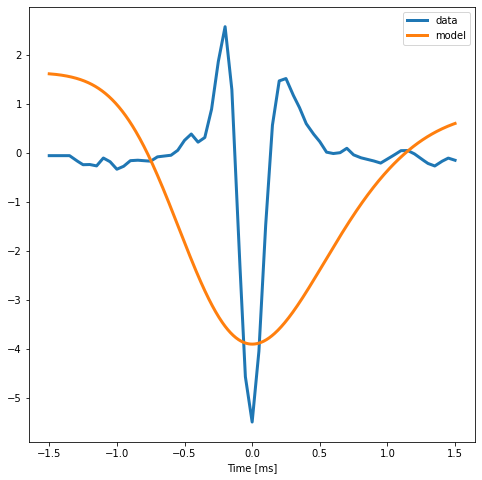

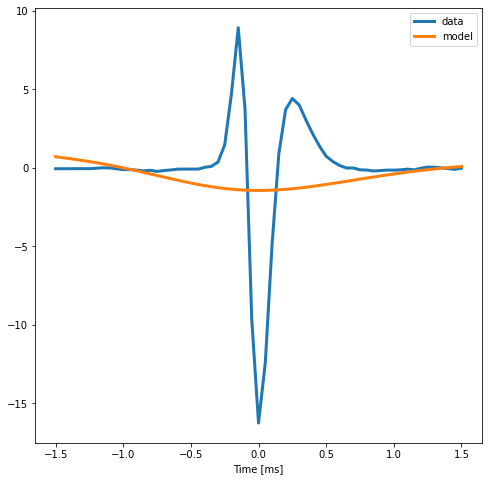

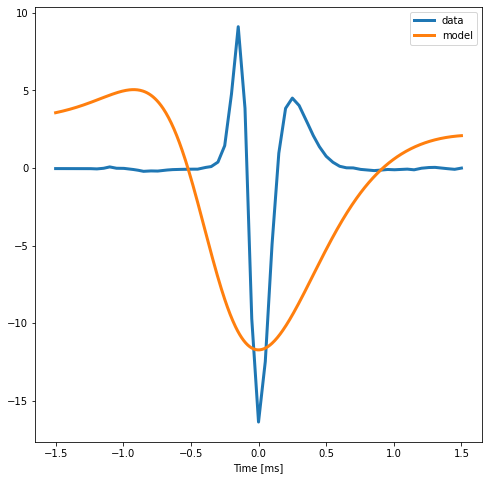

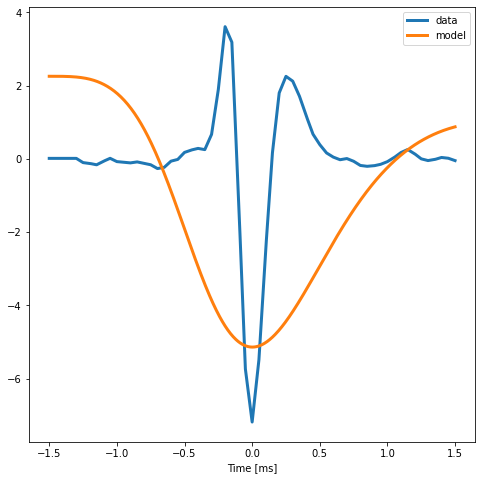

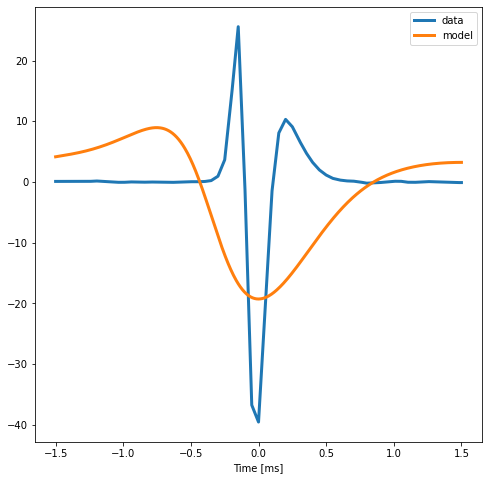

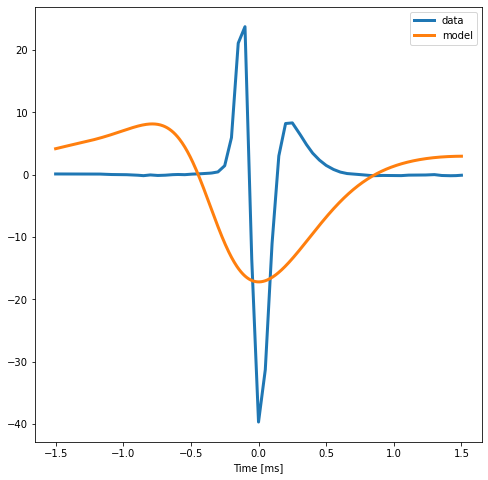

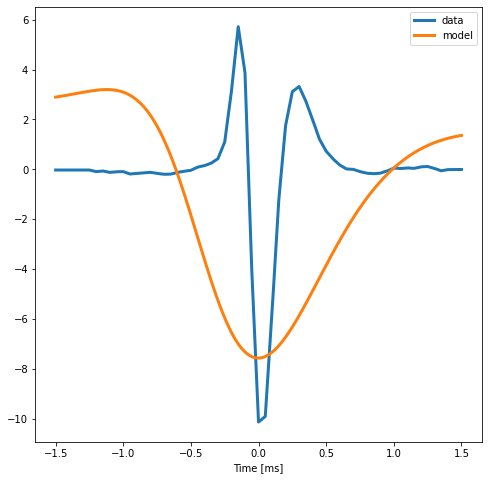

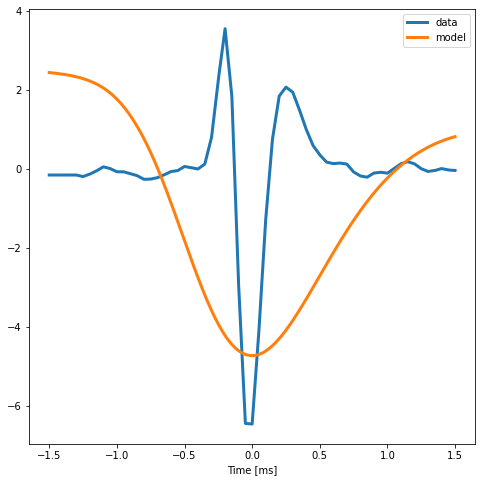

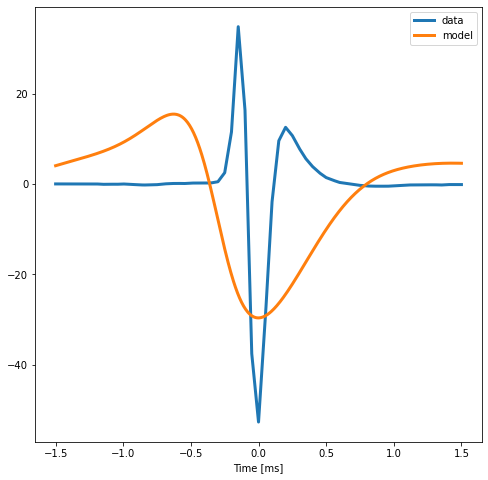

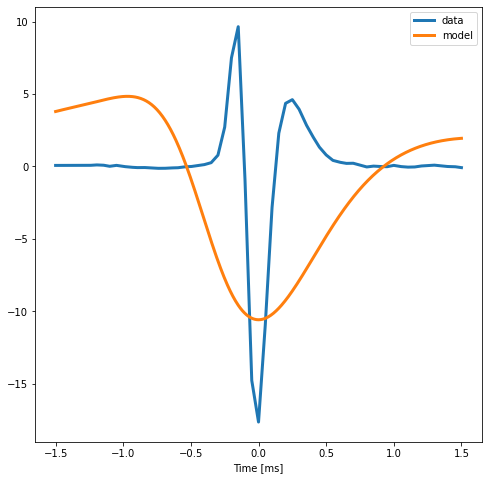

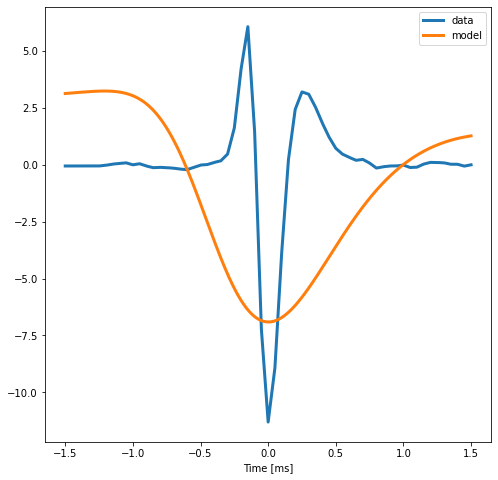

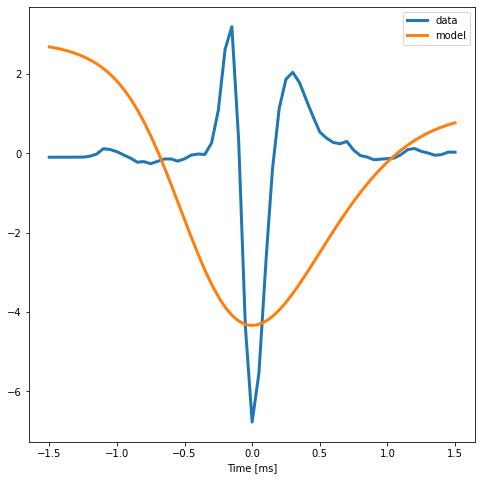

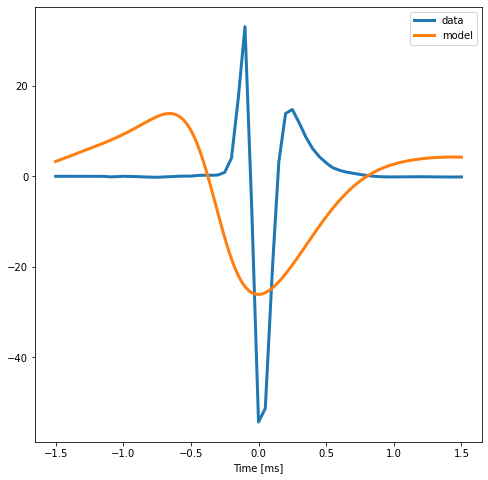

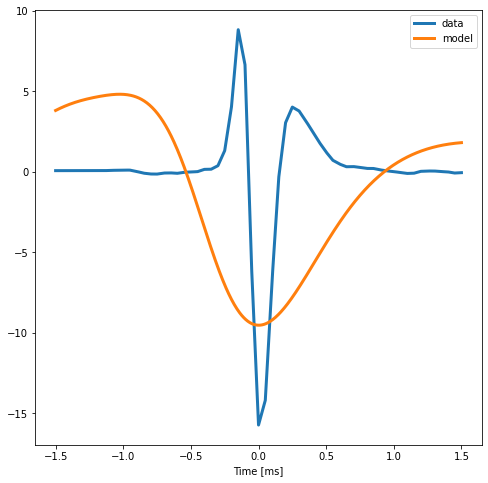

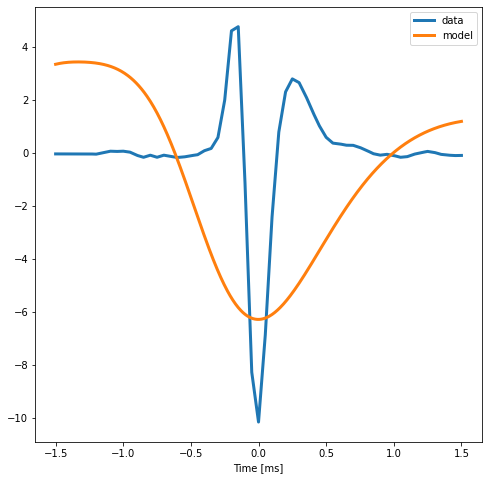

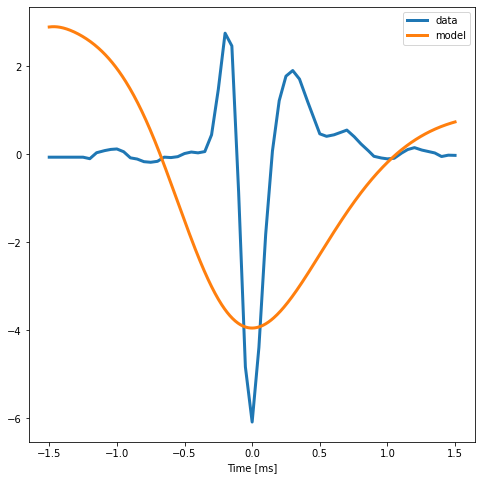

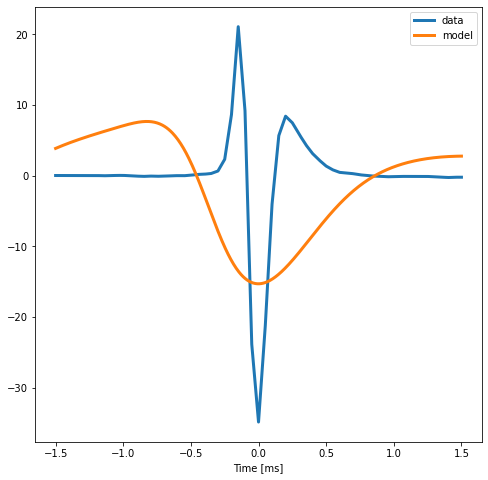

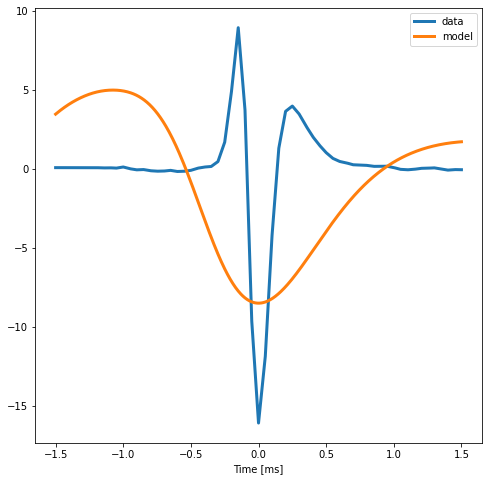

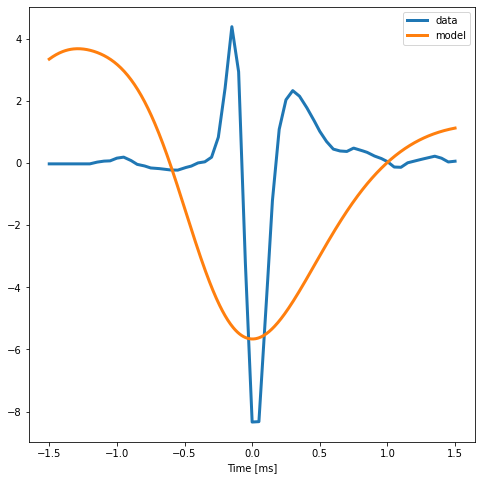

In [763]:
# Uncomment if you want to inspect the fits

for ii in range(20):
    fig = plt.figure(figsize=(8,8))
    ax = fig.add_subplot(111)
    # ax x-asis is time with units of ms
    ax.plot(t,ei_real[ii], linewidth=3, label='data')
    ax.plot(t,ei_sim[ii], linewidth=3, label='model')
    ax.set_xlabel('Time [ms]')
    ax.legend()

## Compute the peak cross-correlation between the sim and data

### Peak cross-correlation, normalized by product of signal norms

In [764]:
cross_corr = []
for real_row,sim_row in zip(ei_real, ei_sim):
    corr_vector = np.correlate(real_row, sim_row, mode='full')

    # Compute norms of the two signals for normalization 
    norm_real = np.linalg.norm(real_row)
    norm_sim = np.linalg.norm(sim_row)

    # Normalize the cross-correlation vector
    corr_vector = corr_vector / (norm_real * norm_sim)

    max_corr = np.max(corr_vector)
    cross_corr.append(max_corr)

print(np.mean(cross_corr))

0.28483207264946475


### Correlation of signal power detected on the electrodes

In [765]:
# Compute correlation on signal power only
power_real = np.sum(np.square(ei_real),axis=1)
power_sim = np.sum(np.square(ei_sim),axis=1)

# Calculate the correlation coefficient
corr_power = np.corrcoef(power_real, power_sim)[0, 1]
print(corr_power)

0.921051774769349


In [766]:
power_corr = []
for real_row,sim_row in zip(ei_real, ei_sim):
    power_real = np.square(real_row)
    power_sim = np.square(sim_row)

    corr_vector = np.correlate(power_real, power_sim, mode='full')

    # Compute norms of the two signals for normalization 
    norm_real = np.linalg.norm(power_real)
    norm_sim = np.linalg.norm(power_sim)

    # Normalize the cross-correlation vector
    corr_vector = corr_vector / (norm_real * norm_sim)

    max_corr = np.max(corr_vector)
    power_corr.append(max_corr)

print(np.mean(power_corr))

0.706358736711676


In [767]:
# Compute cosine similarity between the matricies

# Function to compute cosine similarity between two vectors
def cosine_similarity(A, B):
    dot_product = np.dot(A, B)
    norm_A = np.linalg.norm(A)
    norm_B = np.linalg.norm(B)
    return dot_product / (norm_A * norm_B)

# Compute cosine similarity for each row
cosine_similarities = []
for row_A, row_B in zip(ei_real, ei_sim):
    similarity = cosine_similarity(row_A, row_B)
    cosine_similarities.append(similarity)

# Convert to array for easier manipulation (optional)
cosine_similarities = np.array(cosine_similarities)

print(np.mean(cosine_similarities))

0.20219838408000712


# Scrap below

In [132]:
# For the signal on each electrode, calculate the correlation betwwen the real and simulated signal
correlations = []
for row1, row2 in zip(ei1_window, ei2_window):
    corr = np.corrcoef(row1, row2)[0, 1]
    correlations.append(corr)

# Compute correlation on signal power only
power_real = np.sum(np.square(ei1_window),axis=1)
power_sim = np.sum(np.square(ei2_window),axis=1)

# Calculate the correlation coefficient
corr_power = np.corrcoef(power_real, power_sim)[0, 1]
print(corr_power)

# Average correlation
avg_corr = np.mean(correlations)
print(avg_corr)


0.738119656827475
0.4008791498067381


### Function to help with EI axon or soma findings

In [136]:
def axonorsoma(wave, upBound=1.6, lowBound=0.05):
    try:
        # Get index and value of negative min
        minind = np.argmin(wave)
        minval = np.min(wave)   

        # Get max vals to either side of min
        maxValLeft = np.max(wave[0:minind])
        maxValRight = np.max(wave[minind:])

        # Logic to figure out what compartmeent the wave is from
        if np.abs(minval) < max(maxValLeft,maxValRight):
            cpmt = 'dendrite'
        else:
            if maxValRight == 0:
                ratio = 0
            else:
                ratio = maxValLeft/maxValRight
            if ratio > upBound:
                cpmt = 'axon'
            elif ratio < lowBound:
                cpmt = 'soma'
            else:
                cpmt = 'mixed'
    except ValueError:
        cpmt = 'error'

    return cpmt

In [194]:
def somaLoc(ei):
    # Minimum amplitude criteria for valid electrodes 
    valid_elecs = [elec for elec in range(ei.shape[0]) if 3.6*np.min(ei[elec]) < -10]

    print(valid_elecs)

    # Get collection of soma electrodes 
    soma_electrodes = np.array([elec for elec in valid_elecs if (axonorsoma(ei[elec]) == 'soma' or axonorsoma(ei[elec]) == 'mixed')])

    # Get electrode map
    electrodes = hf.generate_electrode_map(519)
    
    # Get length of soma_electrodes, if zero throw an error
    if len(soma_electrodes) == 0:
        raise ValueError('No soma electrodes detected in ei')
    else:
        # Compute center of mass
        weights = np.array([np.abs(np.amin(ei[soma_elec])) for soma_elec in soma_electrodes])
        weighted_sum = np.sum(weights)
        soma_x = np.dot(weights, electrodes[soma_electrodes,0]) / weighted_sum
        soma_y = np.dot(weights, electrodes[soma_electrodes,1]) / weighted_sum
    
    return soma_x, soma_y, soma_electrodes


In [ ]:
def axonFit(ei, thr=-1, distThr=175, fit_type='quadratic', valid_type='loose'):
    return False

## Write some code to automatically place model cells using the EIs

In [195]:
# Start with full real EI
ei_real = vcd.get_ei_for_cell(535).ei
print(ei_real.shape)

# collapse ei into just minimum for every row, call it ei_min
ei_min_real = -3.6*np.min(ei_real,axis=1) # convert to uV
print(ei_min_real.shape)

elec = hf.generate_electrode_map(519)

(519, 61)
(519,)


In [196]:
soma_x, soma_y, soma_electrodes = somaLoc(ei_real)
print(soma_x, soma_y)

[12, 13, 21, 22, 25, 26, 30, 31, 34, 35, 39, 40, 43, 44, 48, 49, 52, 53, 57, 58, 61, 62, 66, 67, 70, 71, 75, 76, 79, 80, 85, 88, 89, 97, 98, 107, 115, 155, 339, 415, 416, 423, 424, 425, 426, 431, 432, 433, 434, 435, 436, 438, 439, 440, 441, 442, 443, 444, 445, 446, 447, 448, 449, 450, 451, 452, 453, 454, 455, 456, 457, 458, 459, 460, 461, 462, 463, 464, 466, 467, 468, 469, 470, 471, 472, 475, 476, 477, 478, 479, 480, 481, 482, 485, 486, 487, 488, 489, 490, 491, 492, 495, 496, 497, 498, 499, 503, 504, 505]
47.841861923838415 -131.9103931525597


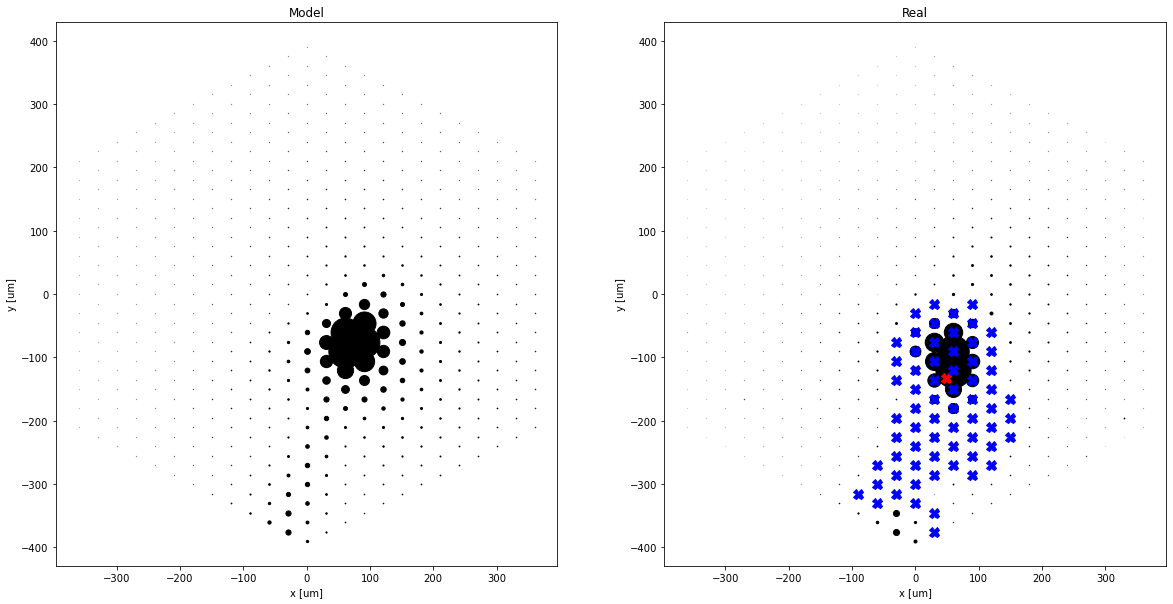

In [197]:
# plot electrode array using plt
fig = plt.figure(figsize=(20,10))

# side by side subplots

ax = fig.add_subplot(121)
ax2 = fig.add_subplot(122)
                    
for ii,elec in enumerate(electrodes):
    # ax.plot(elec[0],elec[1],'o',color='grey',markersize=2,alpha=0.8)
    # ax2.plot(elec[0],elec[1],'o',color='grey',markersize=2,alpha=0.8)

    ax.plot(elec[0],elec[1],'o',color='grey',markersize=0.5,alpha=0.2)
    ax.plot(elec[0],elec[1],'o',color='black',markersize=ei_min_sim[ii]*.08)
    ax2.plot(elec[0],elec[1],'o',color='grey',markersize=0.5,alpha=0.2)
    ax2.plot(elec[0],elec[1],'o',color='black',markersize=ei_min_real[ii]*.08)

    
# # ----------------- plot somaLoc estimate -----------------
ax2.plot(soma_x,soma_y,'X',color='red',markersize=10)
# # ----------------- plot X on selected electrodes -----------------
electrodes_to_plot = soma_electrodes

for elec in electrodes_to_plot:
    ax2.plot(electrodes[elec][0],electrodes[elec][1],'X',color='blue',markersize=10)
# # ----------------- plot X on selected electrodes -----------------

# electrodes_to_plot = [482,444]

# for elec in electrodes_to_plot:
#     ax.text(electrodes[elec][0],electrodes[elec][1],str(elec),fontsize=10)
#     ax2.text(electrodes[elec][0],electrodes[elec][1],str(elec),fontsize=10)

# ------------ plot electrode numbers -----------
# k = 1
# for elec in electrodes:
#     # Plot electrode number identified by str(k) at electrode locations
#     ax.text(elec[0]+5,elec[1]+5,str(k),fontsize=10)
#     k += 1
# ------------ plot electrode numbers -----------

ax.set_aspect('equal')
ax2.set_aspect('equal')
ax.set_title('Model')
ax2.set_title('Real')
ax.set_xlabel('x [um]')
ax.set_ylabel('y [um]')
ax2.set_xlabel('x [um]')
ax2.set_ylabel('y [um]')
# plt.savefig("figures/figure2_A.pdf",format="pdf", bbox_inches="tight")
plt.show()

## Everything below is scrap

In [26]:
datapath = '/Volumes/Analysis/2020-10-06-7/kilosort_data000/data000'
datarun = 'data000'
vcd = vl.load_vision_data(datapath,datarun,
                          include_neurons=True,
                          include_ei=True,
                          include_params=True,
                          include_noise=True)

# look at only sorted parasol cells
cellids = vcd.get_all_cells_similar_to_type('parasol')

In [27]:
print(cellids)

[336, 504, 507, 509, 351, 220, 535, 242, 244, 395, 78, 81, 399, 84, 608, 259, 419, 621, 623, 626, 426, 275, 282, 283, 439, 442, 166, 444, 171, 447, 292, 296, 301, 302, 458, 311, 487, 490]


In [28]:
high_snr_cells = []
for cell in cellids:
    # Extract EI and specifically max EI value
    ei_real = vcd.get_ei_for_cell(cell).ei
    ei_min_real = -1*np.min(ei_real,axis=1)
    
    if np.max(ei_min_real) > (200/3.6) and np.max(ei_min_real) < 300:
        print('High signal cell: ', cell)
        high_snr_cells.append(cell)
        


High signal cell:  504
High signal cell:  509
High signal cell:  351
High signal cell:  535
High signal cell:  244
High signal cell:  78
High signal cell:  81
High signal cell:  84
High signal cell:  259
High signal cell:  621
High signal cell:  623
High signal cell:  426
High signal cell:  283
High signal cell:  439
High signal cell:  442
High signal cell:  447
High signal cell:  458
High signal cell:  311
High signal cell:  490
